# Step 5 -- explicit regularisation (smoothness + soft bounds + no-emission)

Wraps the step-4 PINN with `regularizers.py`. Loss `L = chi2 + R_smooth + R_bound`.
The step-4 fit hit the noise floor but the background/cloud split was degenerate:
the background grew **emission peaks** the clouds cancelled. Here we (i) smooth the
background hard in space+time via autograd coordinate derivatives, (ii) cap the
background spectrum at the continuum (**no-emission** hinge), and (iii) put light
smoothing + physical hinges on the clouds. Success = the background loses its
emission spikes **while** chi2 stays near the photon-noise floor and the `vlos`
maps gain structure. The real work is the **weight scan** in the `REG` cell.


In [1]:
import sys, os
sys.path.insert(0, '..')          # cloud_model_torch.py / utils.py (repo root)

import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from pca_background import fit_background_basis
from pinn_model import ParameterField, grid_coords, composite_synth, chi2_per_pixel
import regularizers as R
from regularizers import regularization_loss, expand_group_config

%load_ext autoreload
%autoreload 2


In [ ]:
# ---- configuration: LARGER assessable test (still laptop-scale) ----
N_BASIS = 10
K       = 6
LAM     = slice(100, 500)

# fit window (bigger than the first smoke test so maps show real structure)
T0   = 13
N_T  = 16          # frames -> exercises temporal regularisation
CROP = 64          # CROP x CROP spatial crop

# neural field
# The Fourier bandwidths live in NORMALISED [-1,1] coords, so a FIXED sigma means a
# coarser physical resolution as the domain grows (step-6 outline sec.4). Define them
# at a reference window and SCALE with CROP / N_T so the tuned per-pixel / per-frame
# resolution transfers -- otherwise growing N_T (4 -> 16) over-smooths hard in time.
N_FREQ    = 128
CROP_REF  = 40; SIGMA_XY_REF = 4.0     # spatial bandwidth calibrated at CROP_REF
N_T_REF   = 4;  SIGMA_T_REF  = 2.0     # temporal bandwidth calibrated at N_T_REF
SIGMA_XY  = SIGMA_XY_REF * CROP / CROP_REF     # keeps cycles-per-pixel ~constant
SIGMA_T   = SIGMA_T_REF  * N_T  / N_T_REF      # keeps cycles-per-frame ~constant
WIDTH     = 256
DEPTH     = 4
S_MAX     = 0.7    # S in [0, S_MAX]; < 1 stops clouds emitting near the continuum
DV_FLOOR  = 8.0    # dv >= DV_FLOOR (km/s), the ~thermal floor

# training (cosine-annealed Adam). Fewer iters than the 50k run: long training against
# the SOFT caps invites slow degeneracy creep; ~5k with the scaled sigmas + the
# background anchor should converge cleanly. Larger BATCH = cleaner gradients on GPU.
N_ITERS   = 5000
LR        = 5e-3
GRAD_CLIP = 1.0
BATCH     = 4096   # None = full batch; int = minibatch over coordinates

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
# data path auto-detects across machines
_CANDS = ['/dat/milic/MiHI_filament/mihi_all_data.npz',
          '/home/milic/data/MiHI_halpha_filament/mihi_all_data.npz']
DATA_NPZ = next((p for p in _CANDS if os.path.exists(p)), _CANDS[0])
device   = torch.device(DEVICE)
print("device:", device, "| data:", DATA_NPZ)
print("SIGMA_XY %.2f (CROP %d)  |  SIGMA_T %.2f (N_T %d)" % (SIGMA_XY, CROP, SIGMA_T, N_T))


In [ ]:
# ---- REG: regularisation config (THE thing to scan). Grouped, human-facing. ----
# w_xy/w_t : space / time smoothness weight per group (autograd |grad p|^2).
# lo/hi + w_lo/w_hi : soft one-sided quadratic hinges  w*<ReLU(.)^2>.
# no_emission : upper hinge on the background SPECTRUM (caps b = mu+c@V at ~1).
# anchor : L2 pull of the background coeffs c toward the filament-free reference
#          c_ref (built in the load cell). This is the fix for the core-FILLING
#          degeneracy the <=1 cap cannot see -- the background flattening its
#          H-alpha core UP to the continuum while the clouds over-absorb.
# bkg smoothing is back to 0.2 (0.5 was OVER-smoothing at CROP=64/N_T=16); the
# scaled sigmas + the anchor now do the heavy lifting on the background.
REG = {
    'bkg':  dict(w_xy=2e-1, w_t=2e-1),                             # moderate background smoothing
    'S':    dict(w_xy=1e-3, w_t=1e-3, lo=0.0,   w_lo=1e-2),
    'dtau': dict(w_xy=1e-3, w_t=1e-3, lo=0.0,   w_lo=1e-2),
    'vlos': dict(w_xy=1e-3, w_t=1e-3, lo=-60.0, hi=60.0, w_lo=1e-2, w_hi=1e-2),
    'dv':   dict(w_xy=1e-3, w_t=1e-3, lo=8.0,   w_lo=1e-2),
    'no_emission': dict(weight=5e1, cap=1.0),                      # forbid background emission (b > 1)
    'anchor':      dict(weight=1e-1),                             # <-- KEY new knob: pull bkg -> filament-free c_ref
}
regw = expand_group_config(REG)   # -> per-field (P,) vectors, expanded once
print('fields:', R.FIELD_NAMES)
print('w_xy  :', regw['w_xy'].numpy().round(4))
print('no-emission weight:', regw['no_weight'], '| cap:', regw['no_cap'],
      '| anchor weight:', regw['anchor_weight'])


In [ ]:
# ---- load cube once; build the step-1 basis; carve the fit window ----
f    = np.load(DATA_NPZ, allow_pickle=True)
wav  = np.asarray(f['wav'])
cube = f['data']                                             # (t, y, x, lambda)

YS, XS = slice(15, -15), slice(15, -15)
blk = np.copy(cube[-N_BASIS:, YS, XS, LAM]).astype(np.float32)
Iqs = float(blk[..., -20:].mean())

full   = cube[:, YS, XS, LAM]
Ny, Nx = full.shape[1], full.shape[2]
cy, cx = Ny // 2, Nx // 2
ys = slice(cy - CROP // 2, cy - CROP // 2 + CROP)
xs = slice(cx - CROP // 2, cx - CROP // 2 + CROP)
ts = list(range(T0 - N_T // 2, T0 - N_T // 2 + N_T))
obs = np.copy(full[ts][:, ys, xs, :]).astype(np.float32) / Iqs
del f, cube, full

Nt, Cy, Cx, L = obs.shape
xl  = [np.copy(wav[LAM]).astype(np.float32), np.asarray([np.mean(wav[LAM])], dtype=np.float32)]
pca = fit_background_basis(blk, n_snapshots=N_BASIS, n_components=K, normalization=Iqs)

obs_pt = torch.from_numpy(obs.reshape(-1, L)).to(device)
coords = grid_coords(Nt, Cy, Cx, device=device).requires_grad_(True)  # autograd smoothness

# background-anchor reference: the filament-free last-N-frame MEAN profile per crop
# pixel, projected onto the basis -> c_ref. The anchor pulls the fitted background
# coeffs c toward this quiet-Sun profile (which keeps its H-alpha absorption line),
# instead of letting the core fill up to the continuum. Use these last-N frames
# (filament-free), NOT the observed projection of the fit window (which already
# contains the absorption -- the freeze test showed that route fails). Tiled over
# the Nt fit frames to match the (t, y, x) ordering of coords / obs_pt.
ref_spec = blk[:, ys, xs, :].mean(0) / Iqs                    # (Cy, Cx, L)
ref_pt   = torch.from_numpy(ref_spec.reshape(-1, L).astype(np.float32)).to(device)
c_ref    = pca.project(ref_pt, k=K).repeat(Nt, 1).detach()    # (Nt*Cy*Cx, K)

print(pca)
print("frames:", ts, "| crop:", (Cy, Cx), "| N samples:", coords.shape[0], "| L:", L)
print("c_ref:", tuple(c_ref.shape), "| anchor ref = filament-free last-%d-frame background" % N_BASIS)

In [18]:
# ---- neural field; background bias set to the field-average background ----
bkg_bias = pca.project(obs_pt, k=K).mean(0).detach().cpu()          # (K,)
field = ParameterField(d_in=3, n_freq=N_FREQ, sigmas=(SIGMA_XY, SIGMA_XY, SIGMA_T),
                       width=WIDTH, depth=DEPTH, s_max=S_MAX, dv_floor=DV_FLOOR,
                       bkg_bias=bkg_bias).to(device)
print("field weights:", sum(p.numel() for p in field.parameters()),
      "| Fourier out dim:", field.ff.n_out)

with torch.no_grad():
    c0, pc0 = field(coords)
    syn0    = composite_synth(xl, pca, c0, pc0, loga_clamp=None)
    _, l0   = chi2_per_pixel(obs_pt, syn0, reduce_mean=True)
print("init cloud means [S1,tau1,v1,dv1,loga1,S2,tau2,v2,dv2,loga2]:",
      pc0.mean(0).cpu().numpy().round(2))
print("initial loss:", round(float(l0), 4), "| all finite:", bool(torch.isfinite(syn0).all()))

field weights: 266766 | Fourier out dim: 256
init cloud means [S1,tau1,v1,dv1,loga1,S2,tau2,v2,dv2,loga2]: [  0.2    4.5  -19.99  12.    -4.     0.6    4.5   19.99  12.    -5.  ]
initial loss: 7.2184 | all finite: True


In [19]:
# ---- gradient check: loss -> network weights ----
for p in field.parameters():
    p.grad = None
c, pc = field(coords)
_, loss = chi2_per_pixel(obs_pt, composite_synth(xl, pca, c, pc, loga_clamp=None), reduce_mean=True)
loss.backward()
gnorm = sum(float(p.grad.norm()) for p in field.parameters() if p.grad is not None)
print("params with grad:", sum(p.grad is not None for p in field.parameters()),
      "/", len(list(field.parameters())), "| total grad norm:", round(gnorm, 4))

params with grad: 10 / 10 | total grad norm: 10.1703


In [ ]:
# ---- train: chi2 + regularisation (cosine-annealed Adam, grad clip, timed) ----
from tqdm.auto import trange
from torch.optim.lr_scheduler import CosineAnnealingLR
opt   = torch.optim.Adam(field.parameters(), lr=LR)
sched = CosineAnnealingLR(opt, T_max=N_ITERS, eta_min=LR * 0.05)
hist, hist_data, hist_reg = [], [], []
n = coords.shape[0]
t_start = time.time()
for it in trange(N_ITERS):
    opt.zero_grad()
    if BATCH is None:
        cb, ob, cr = coords, obs_pt, c_ref
    else:
        idx = torch.randint(0, n, (BATCH,), device=device)
        cb  = coords[idx].detach().requires_grad_(True)   # clean leaf for autograd smoothness
        ob  = obs_pt[idx]
        cr  = c_ref[idx]                                  # SAME pixels -> anchor reference
    c, pc = field(cb)
    _, data = chi2_per_pixel(ob, composite_synth(xl, pca, c, pc, loga_clamp=None), reduce_mean=True)
    reg  = regularization_loss(c, pc, cb, pca, weights=regw, c_ref=cr)
    loss = data + reg['total']
    if not torch.isfinite(loss):
        print('non-finite loss at iter', it, '-- stopping'); break
    loss.backward()
    torch.nn.utils.clip_grad_norm_(field.parameters(), GRAD_CLIP)
    opt.step(); sched.step()
    hist.append(float(loss)); hist_data.append(float(data)); hist_reg.append(float(reg['total']))
dt = time.time() - t_start; ms = 1e3 * dt / max(len(hist), 1)
print('total %.4e -> %.4e | data %.4e | reg %.4e | %.1f s, %.1f ms/iter'
      % (hist[0], hist[-1], hist_data[-1], hist_reg[-1], dt, ms))
print('  reg parts (final): ' + ', '.join('%s=%.3e' % (k, float(v))
      for k, v in regularization_loss(*field(coords), coords, pca, weights=regw, c_ref=c_ref).items() if k != 'total'))
plt.figure(figsize=(5.2, 3)); plt.semilogy(hist, label='total'); plt.semilogy(hist_data, label='data (chi2)')
plt.semilogy(hist_reg, label='reg'); plt.legend(); plt.xlabel('iteration'); plt.ylabel('loss')
plt.title('PINN loss (step 5)')


background peak / continuum : median 1.018  |  95th 1.026  |  max 1.101
fraction of pixels >5% into emission : 2.2%   (step-4 reg-off: ~100% at ~5x)


Text(0.5, 1.0, 'background emission check')

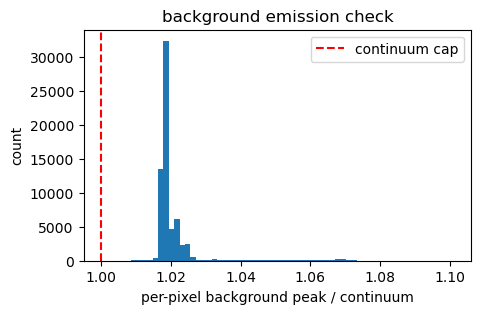

In [21]:
# ---- DIAGNOSTIC: did the background lose its emission spikes? ----
# The step-4 pathology: background spectra develop peaks well above the continuum
# (~1 in Iqs units) that the clouds then absorb. The MAGNITUDE of the peak is the
# real metric (a 12x12x2 crop: step-4/reg-off ~4.9x median, calibrated reg ~1.1x).
with torch.no_grad():
    c_all, _ = field(coords)
    bkg  = pca.reconstruct(c_all)                     # (N, L) background spectra
    peak = bkg.max(dim=1).values                      # per-pixel max over wavelength
    cap  = float(regw['no_cap'])
    frac = float((peak > cap + 0.05).float().mean())  # >5%% into emission
    print('background peak / continuum : median %.3f  |  95th %.3f  |  max %.3f'
          % (peak.median(), peak.quantile(0.95), peak.max()))
    print('fraction of pixels >5%% into emission : %.1f%%   (step-4 reg-off: ~100%% at ~5x)'
          % (100 * frac))
plt.figure(figsize=(5, 3)); plt.hist(peak.cpu().numpy().ravel(), bins=60)
plt.axvline(cap, color='r', ls='--', label='continuum cap'); plt.legend()
plt.xlabel('per-pixel background peak / continuum'); plt.ylabel('count')
plt.title('background emission check')


In [22]:
# ---- QUANTITATIVE SUMMARY (robust even without the plots) ----
with torch.no_grad():
    c_all, p_all = field(coords)
    syn = composite_synth(xl, pca, c_all, p_all, loga_clamp=None)
resid   = obs_pt - syn
chi2v   = (resid ** 2).sum(-1)
rms_pct = 100.0 * float(torch.sqrt((resid ** 2).mean())) / float(obs_pt.mean())
print("final mean per-pixel chi2:", round(float(chi2v.mean()), 4),
      "| median:", round(float(chi2v.median()), 4),
      "| p95:", round(float(torch.quantile(chi2v, 0.95)), 4))
print("RMS residual: %.3f %% of mean intensity" % rms_pct)
names = ['S1', 'tau1', 'v1', 'dv1', 'loga1', 'S2', 'tau2', 'v2', 'dv2', 'loga2']
pn = p_all.cpu().numpy()
print("param    min /  median /  max")
for j, nm in enumerate(names):
    col = pn[:, j]
    print("  %-6s % .2f / % .2f / % .2f" % (nm, col.min(), np.median(col), col.max()))

final mean per-pixel chi2: 0.4679 | median: 0.3384 | p95: 1.1792
RMS residual: 5.387 % of mean intensity
param    min /  median /  max
  S1      0.21 /  0.84 /  1.00
  tau1    0.10 /  1.00 /  6.19
  v1     -53.07 / -47.88 / -40.95
  dv1     21.66 /  23.84 /  26.04
  loga1  -4.00 / -4.00 / -4.00
  S2      0.20 /  0.49 /  1.00
  tau2    0.18 /  0.88 /  3.91
  v2      8.03 /  13.57 /  23.07
  dv2     24.82 /  32.55 /  46.66
  loga2  -5.00 / -5.00 / -5.00


Text(0.5, 0.98, 'Observed (top) vs fitted (bottom), frame 13')

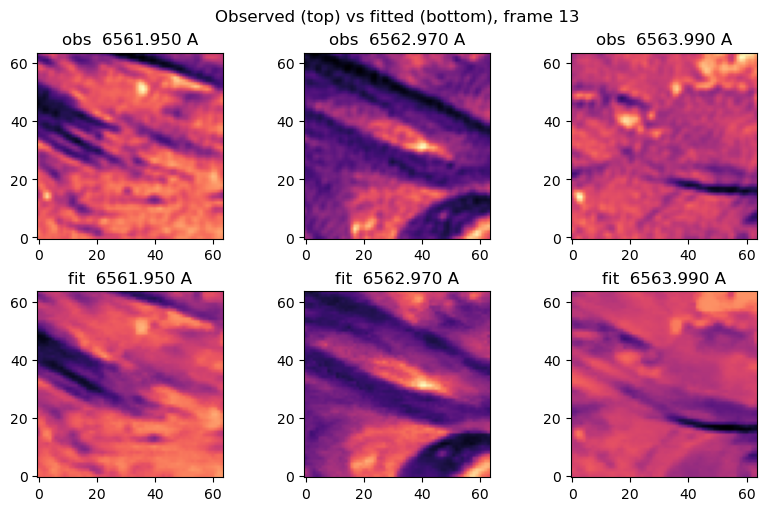

In [28]:
# ---- observed vs fitted image maps at 3 wavelengths (centre frame) ----
kf = N_T // 2; core = L // 2; wl = wav[LAM]
oc = obs_pt.cpu().numpy().reshape(N_T, CROP, CROP, L)[kf]
fc = syn.cpu().numpy().reshape(N_T, CROP, CROP, L)[kf]
wl_idx = [max(core - 120, 0), core, min(core + 120, L - 1)]
fig, ax = plt.subplots(2, 3, figsize=(8, 5), constrained_layout=True)
for j, ii in enumerate(wl_idx):
    vmn = min(oc[:, :, ii].min(), fc[:, :, ii].min()); vmx = max(oc[:, :, ii].max(), fc[:, :, ii].max())
    ax[0, j].imshow(oc[:, :, ii].T, origin='lower', cmap='magma', vmin=vmn, vmax=vmx)
    ax[1, j].imshow(fc[:, :, ii].T, origin='lower', cmap='magma', vmin=vmn, vmax=vmx)
    ax[0, j].set_title('obs  %.3f A' % wl[ii]); ax[1, j].set_title('fit  %.3f A' % wl[ii])
    #for r in (0, 1):
    #    ax[r, j].set_xticks([]); ax[r, j].set_yticks([])
fig.suptitle('Observed (top) vs fitted (bottom), frame %d' % ts[kf])

Text(0.5, 0.98, 'Cloud parameter maps, frame 13')

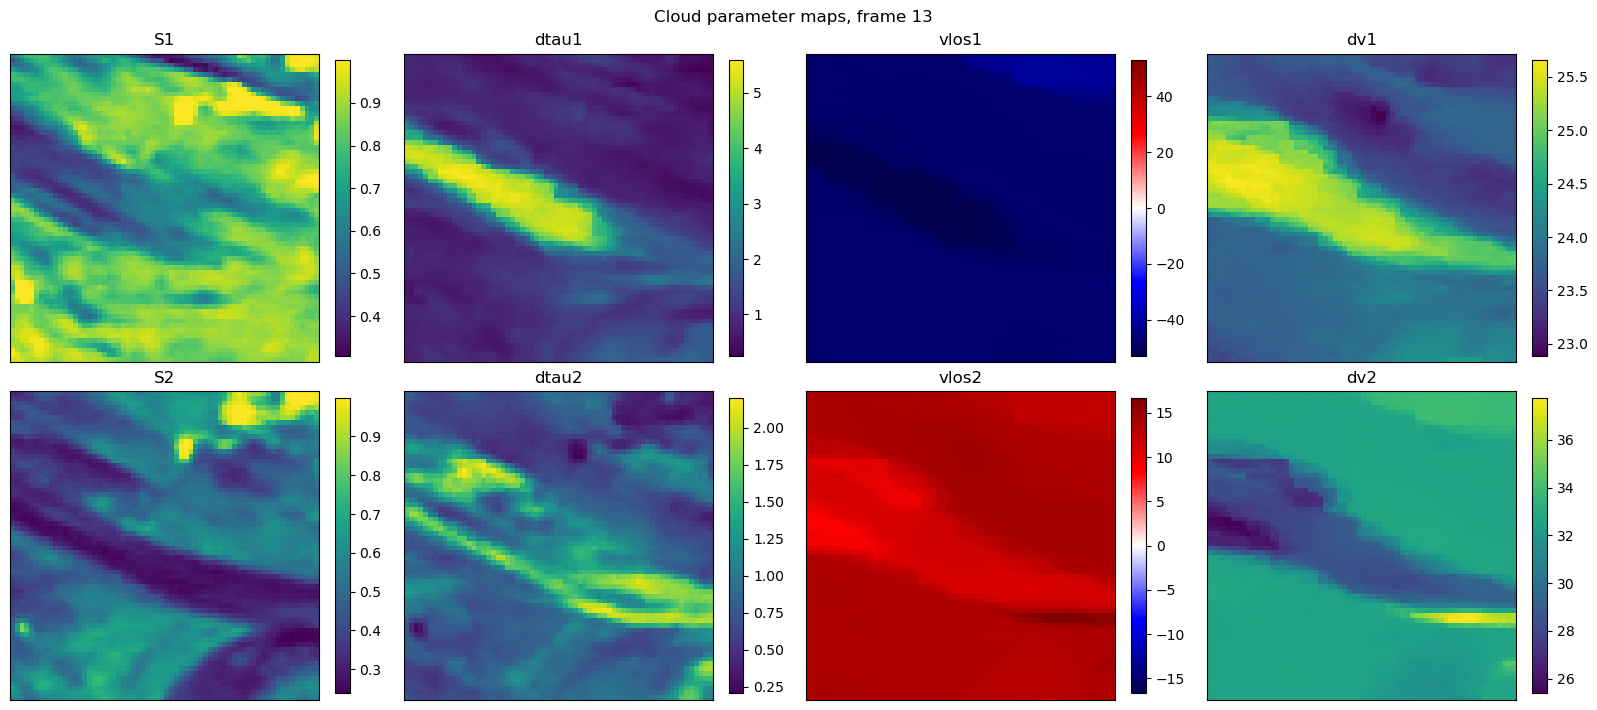

In [29]:
# ---- cloud parameter maps (centre frame) ----
pm = p_all.cpu().numpy().reshape(Nt, Cy, Cx, 10)[kf]
specs = [('S1', 0, 'viridis'), ('dtau1', 1, 'viridis'), ('vlos1', 2, 'seismic'), ('dv1', 3, 'viridis'),
         ('S2', 5, 'viridis'), ('dtau2', 6, 'viridis'), ('vlos2', 7, 'seismic'), ('dv2', 8, 'viridis')]
fig, ax = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True); ax = ax.ravel()
for a, (nm, col, cm) in zip(ax, specs):
    vm = float(np.abs(pm[:, :, col]).max()) if cm == 'seismic' else None
    im = a.imshow(pm[:, :, col].T, origin='lower', cmap=cm,
                  vmin=(-vm if vm else None), vmax=(vm if vm else None))
    a.set_title(nm); a.set_xticks([]); a.set_yticks([]); fig.colorbar(im, ax=a, fraction=0.046)
fig.suptitle('Cloud parameter maps, frame %d' % ts[kf])

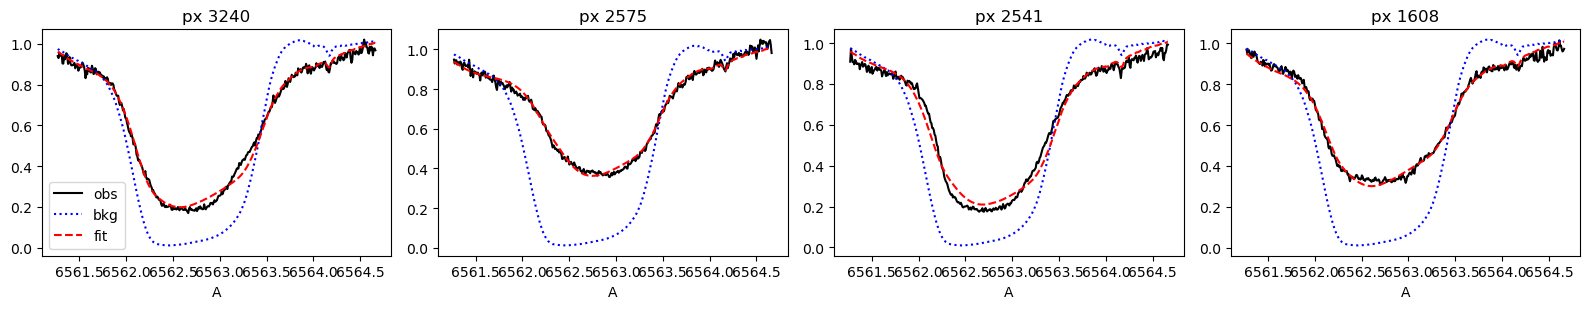

In [30]:
# ---- spectra: observed / background / fit for a few pixels ----
bkg = pca.reconstruct(c_all).detach().cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
o2, f2, b2 = oc.reshape(-1, L), fc.reshape(-1, L), bkg.reshape(-1, L)
np.random.seed(2); ii = np.random.randint(0, Cy * Cx, size=4)
fig, ax = plt.subplots(1, 4, figsize=(16, 3.2))
for j, p in enumerate(ii):
    ax[j].plot(wl, o2[p], 'k', label='obs'); ax[j].plot(wl, b2[p], 'b:', label='bkg')
    ax[j].plot(wl, f2[p], 'r--', label='fit'); ax[j].set_title('px %d' % p); ax[j].set_xlabel('A')
ax[0].legend(); plt.tight_layout()

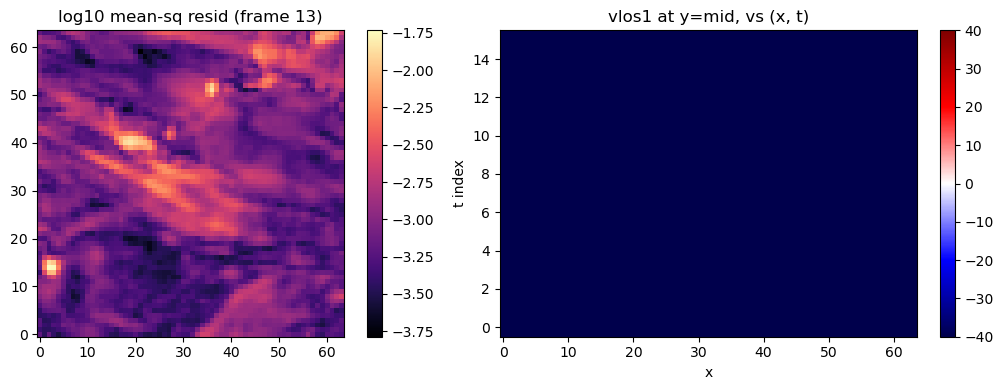

In [31]:
# ---- residual map + temporal smoothness of vlos1 ----
cm2 = ((obs_pt - syn).cpu().numpy() ** 2).mean(-1).reshape(Nt, Cy, Cx)
vlos1 = p_all.cpu().numpy().reshape(Nt, Cy, Cx, 10)[:, :, :, 2]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im0 = ax[0].imshow(np.log10(cm2[kf]).T, origin='lower', cmap='magma')
ax[0].set_title('log10 mean-sq resid (frame %d)' % ts[kf]); fig.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(vlos1[:, Cy // 2, :], origin='lower', aspect='auto', cmap='seismic', vmin=-40, vmax=40)
ax[1].set_title('vlos1 at y=mid, vs (x, t)'); ax[1].set_xlabel('x'); ax[1].set_ylabel('t index')
fig.colorbar(im1, ax=ax[1], fraction=0.046); plt.tight_layout()

In [32]:
# ---- extrapolate cost to the FULL run (linear; sizes the server) ----
N_T_full = 20
N_full   = N_T_full * Ny * Nx
per      = ms / n
fpi      = per * N_full / 1e3
print("now: %.1f ms/iter over %d samples (%.4f ms/sample)" % (ms, n, per))
print("full field %dx%d x %d frames = %d samples/iter" % (Ny, Nx, N_T_full, N_full))
print("linear estimate: ~%.2f s/iter, ~%.1f min for %d iters (CPU-scaled; GPU far faster)"
      % (fpi, fpi * N_ITERS / 60.0, N_ITERS))

now: 43.6 ms/iter over 65536 samples (0.0007 ms/sample)
full field 116x130 x 20 frames = 301600 samples/iter
linear estimate: ~0.20 s/iter, ~167.1 min for 50000 iters (CPU-scaled; GPU far faster)


## Notes

- **Assessing the fit:** the *quantitative summary* cell is the quickest read --
  final/median/p95 per-pixel chi2, RMS % of intensity, and per-parameter min/median/max
  (check the ranges are physical). Then the obs-vs-fit image maps, parameter maps,
  spectra, and residual/temporal panels.
- **Model changes vs the first run:** physical ranges now via smooth transforms in the
  field (`S` sigmoid in [0,S_MAX], `dtau` softplus, `dv` softplus+floor >= DV_FLOOR) --
  no `abs()` sign degeneracy; background bias initialised to the field-average background;
  cosine-annealed Adam, grad clipping, more iterations.
- **Regularisation knobs:** lower `SIGMA_XY`/`SIGMA_T` for smoother maps, raise for detail.
- **To assess together:** run all cells and **save the notebook** so the outputs persist.
- **Scale to the server:** raise `CROP`/`N_T`/`WIDTH`/`DEPTH`/`N_FREQ`, set `BATCH` if
  memory-bound, `device=cuda`. Same code.